# Phase 4 Project: Hybrid Movie Recommendation System

## GROUP 2

## Authors: 
1. Andrew Nyakiba

2. Angela Wachira

3. Bobbin Bodo

4. Mercy Chepkoech

5. Ted Mwenda

### Instructor name: MARYANNE MWIKALI


### Project Type: Recommendation System

### Datasets Used: ratings.csv, movies.csv, tags.csv

This notebook develops a hybrid recommendation system using the MovieLens dataset. It combines collaborative filtering and content-based filtering to generate personalized movie recommendations while also addressing the cold start problem for new users.


# 1. PROJECT OVERVIEW

This project aims to build a personalized movie recommendation system using collaborative filtering on the MovieLens dataset. The system will learn from individual users' explicit ratings to predict which unwatched movies they are most likely to enjoy and should return the top 5 personalized recommendations per user.


# 2. BUSINESS PROBLEM

### 2.1 Stakeholder

The primary stakeholder for this project is a movie streaming platform, Ziki, that wants to improve the quality of user recommendations. Ziki is a fictional Nairobi-based mobile streaming startup targeting the East African market. 


### 2.2 BUSINESS PROBLEM

Streaming platforms offer huge catalogs, but without strong personalization, users face decision fatigue. Ziki offers a large catalog of movies, which can make it difficult for users to quickly find content that matches their preferences, leading to decision fatigue and reduced engagement. The goal of this project is to improve user experience by building a recommendation system that provides the top five personalized movie suggestions based on user ratings and content features.

### 2.3 PRIMARY PROJECT OBJECTIVE

The main objective of this project is to build a hybrid recommendation system that can provide top 5 movie recommendations to a user based on prior preferences. 


### 2.4 Secondary Objectives

To support our recommendation system, this analysis seeks to tackle  the following objectives:

1. To identify top genres with highest rates.

2. To develop a user-interface.

3. To build a collaborative filtering model for user-ratings analysis.

4. To build a content based filtering model for descriptive analysis, and to handle the "cold start" problem.



### 2.5 Key Questions

1. What are the top rated genres?

2. Why a Hybrid System?

3. Why work with the 3 chosen datasets?

4. Are there specific trends or patterns in the movie ratings over time?


### 2.6 Why a Hybrid System?

A purely collaborative model works well when enough user-rating history exists, but it performs poorly for new users and less-rated movies. A hybrid system is therefore more appropriate because it combines:

**Collaborative filtering**  for users with interaction history

**Content-based filtering** using movie genres and user-generated tags for cold start situations














### Importation of Libraries

In [75]:

# Uncomment if scikit-surprise is not installed in your environment
# !pip install scikit-surprise

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, Reader, SVD, KNNBasic, accuracy
from surprise.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)


### 3. Loading data

In [76]:
# Aesthetics
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (10, 6)

# Load the datasets
movies  = pd.read_csv('../Data/ml-latest-small/movies.csv')
ratings = pd.read_csv('../Data/ml-latest-small/ratings.csv')
tags    = pd.read_csv('../Data/ml-latest-small/tags.csv')

print("Datasets loaded successfully.")
print(f"Movies: {movies.shape}, Ratings: {ratings.shape}, Tags: {tags.shape}")


Datasets loaded successfully.
Movies: (9742, 3), Ratings: (100836, 4), Tags: (3683, 4)


In [77]:
# First, merge ratings and movies
df = ratings.merge(movies, on='movieId', how='left')
df

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
...,...,...,...,...,...,...
100831,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller
100832,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller
100833,610,168250,5.0,1494273047,Get Out (2017),Horror
100834,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi


In [78]:
merged = ratings.merge(movies, on="movieId")
merged.to_csv("merged_data.csv", index=False)
# For Tableau

## 4. DATA UNDERSTANDING

### 4.1 Missing Value Analysis

In [79]:
print("Missing values in ratings:")
print(ratings.isna().sum(), end="\n\n")

print("Missing values in movies:")
print(movies.isna().sum(), end="\n\n")

print("Missing values in tags:")
print(tags.isna().sum())

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64


### 4.2 Duplicate Values Analysis

In [80]:
# Check duplicates
print("Duplicate rows in ratings:", ratings.duplicated().sum())
print("Duplicate rows in movies:", movies.duplicated().sum())
print("Duplicate rows in tags:", tags.duplicated().sum())


Duplicate rows in ratings: 0
Duplicate rows in movies: 0
Duplicate rows in tags: 0


### 4.3 Global statistics

In [81]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)
sparsity = 1 - (n_ratings / (n_users * n_movies))

print(f"Unique Users    : {n_users}")
print(f"Unique Movies   : {n_movies}")
print(f"Total Ratings   : {n_ratings}")
print(f"Matrix Sparsity : {sparsity:.2%}")

Unique Users    : 610
Unique Movies   : 9724
Total Ratings   : 100836
Matrix Sparsity : 98.30%


## 5. DATA CLEANING

### Dropping unnecessary columns

In [82]:
# Drop timestamp column
df = df.drop(columns=['timestamp'])

# Confirm
df.head()

,userId,movieId,rating,title,genres
0,1,1,4.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [83]:
df.head()

,userId,movieId,rating,title,genres
0,1,1,4.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


## 6. EXPLORATORY DATA ANALYSIS 

Understanding the distribution of ratings and movie popularity across the Ziki platform.

### 6.1 Ratings and Genre Analysis. 

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211

mean   3.502
median 3.5
std    1.043


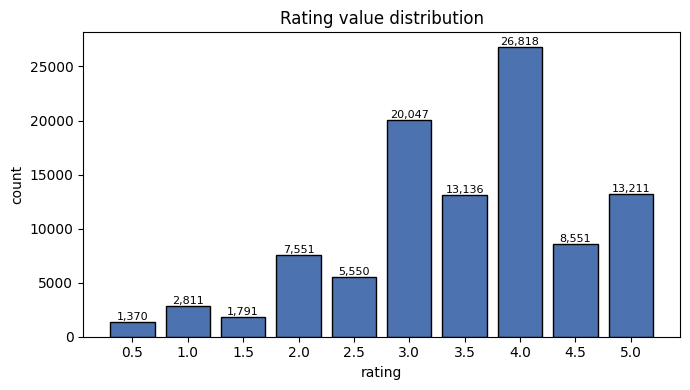

In [85]:
rv = ratings.rating.value_counts().sort_index()
print(rv.to_string())
print(f"\nmean   {ratings.rating.mean():.3f}")
print(f"median {ratings.rating.median():.1f}")
print(f"std    {ratings.rating.std():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rv.index.astype(str), rv.values, color='#4C72B0', edgecolor='black')
for x, y in zip(range(len(rv)), rv.values):
    ax.text(x, y, f'{y:,}', ha='center', va='bottom', fontsize=8)
ax.set_title('Rating value distribution')
ax.set_xlabel('rating'); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

The distribution of ratings is concentrated around the mid-to-high values, with most ratings falling between 3.0 and 5.0. This suggests that users are more likely to rate movies they already have some interest in, resulting in a positive bias in the data. This skew can influence model predictions, as highly rated movies may dominate recommendation outputs.

### 6.2 Top Rated Movies 

In [86]:
# Create movie_ratings dataset (merge + drop unnecessary columns)
movie_ratings = pd.merge(ratings, movies, on='movieId')

In [87]:
movie_rating_summary = movie_ratings.groupby('title').agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count')
).sort_values('rating_count', ascending=False)

movie_rating_summary.head(10)


,avg_rating,rating_count
title,,
Forrest Gump (1994),4.164134,329
"Shawshank Redemption, The (1994)",4.429022,317
Pulp Fiction (1994),4.197068,307
"Silence of the Lambs, The (1991)",4.161290,279
"Matrix, The (1999)",4.192446,278
Star Wars: Episode IV - A New Hope (1977),4.231076,251
Jurassic Park (1993),3.750000,238
Braveheart (1995),4.031646,237
Terminator 2: Judgment Day (1991),3.970982,224


Forrest Gump(1994), is the highest rated movie according to the above summary.

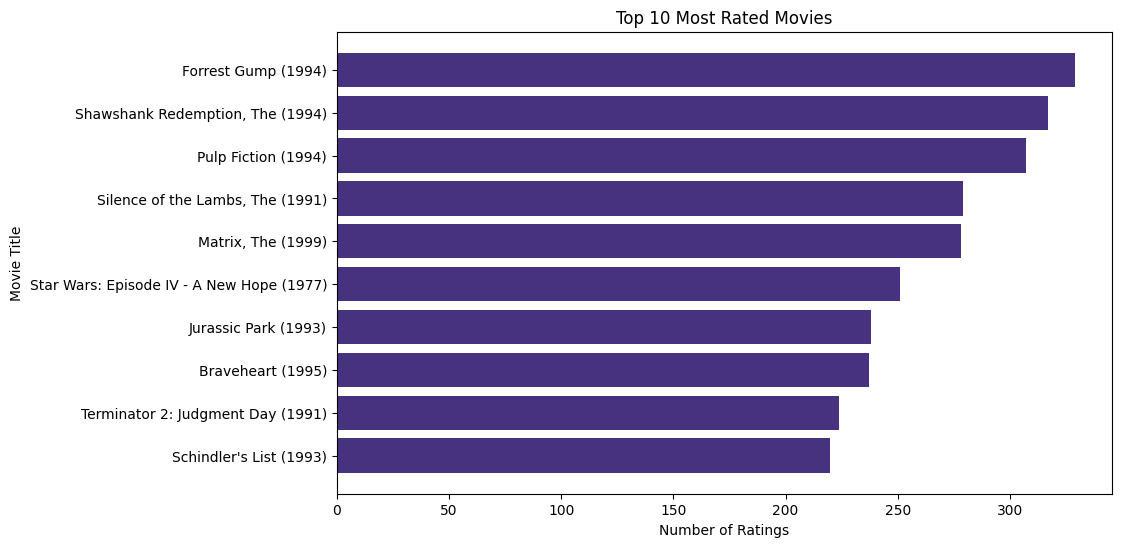

In [88]:
most_rated_movies = movie_rating_summary.head(10).sort_values('rating_count')

plt.figure(figsize=(10,6))
plt.barh(top_movies.index, top_movies['rating_count'])
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()





### Movies With highest Rates

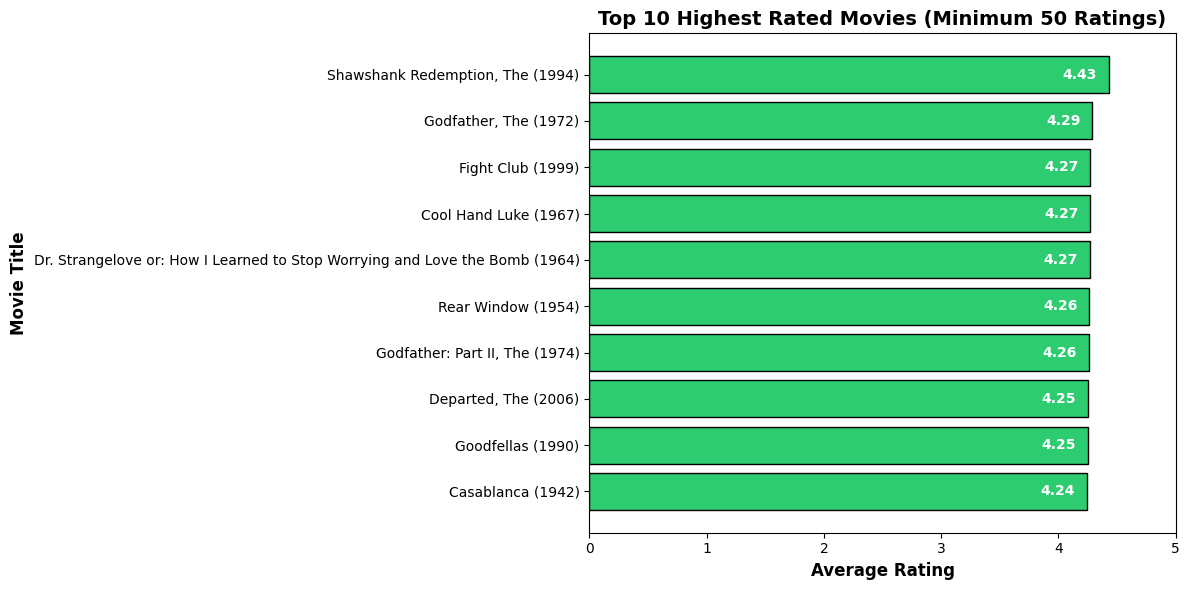


Top 10 Highest Rated Movies (min 50 ratings):


,Movie Title,Number of Ratings,Average Rating
1,"Shawshank Redemption, The (1994)",317,4.429022
2,"Godfather, The (1972)",192,4.289062
3,Fight Club (1999),218,4.272936
4,Cool Hand Luke (1967),57,4.271930
5,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041
6,Rear Window (1954),84,4.261905
7,"Godfather: Part II, The (1974)",129,4.259690
8,"Departed, The (2006)",107,4.252336
9,Goodfellas (1990),126,4.250000
10,Casablanca (1942),100,4.240000


In [89]:
# Top 10 highest rated (minimum 50 ratings to filter out obscure films)
top_rated = movie_rating_summary[movie_rating_summary['rating_count'] >= 50].nlargest(10, 'avg_rating')

# Create a more informative display
fig, ax = plt.subplots(figsize=(12, 6))
top_rated_sorted = top_rated.sort_values('avg_rating')
bars = ax.barh(top_rated_sorted.index, top_rated_sorted['avg_rating'], color='#2ecc71', edgecolor='black')

# Add value labels on bars
for i, (idx, row) in enumerate(top_rated_sorted.iterrows()):
    ax.text(row['avg_rating'] - 0.1, i, f"{row['avg_rating']:.2f}", 
            va='center', ha='right', fontweight='bold', color='white')

ax.set_xlabel('Average Rating', fontsize=12, fontweight='bold')
ax.set_ylabel('Movie Title', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Highest Rated Movies (Minimum 50 Ratings)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()

# Display detailed table
print("\nTop 10 Highest Rated Movies (min 50 ratings):")
display_df = top_rated[['rating_count', 'avg_rating']].reset_index()
display_df.columns = ['Movie Title', 'Number of Ratings', 'Average Rating']
display_df = display_df.sort_values('Average Rating', ascending=False).reset_index(drop=True)
display_df.index = display_df.index + 1
display(display_df)

### 6.3 Top 10 most common genres 

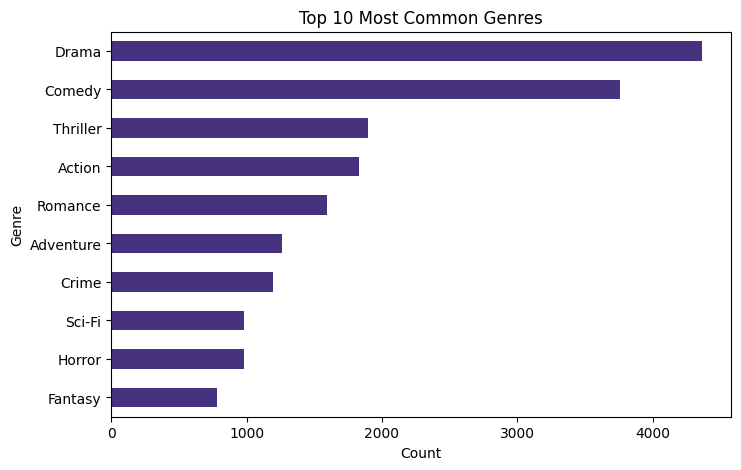

In [90]:
genre_exploded = movies.assign(genres=movies['genres'].str.split('|')).explode('genres')
top_genres = genre_exploded['genres'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_genres.sort_values().plot(kind='barh')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

The dataset is heavily dominated by Drama (4,361) and Comedy (3,756), which together represent the core of the Ziki library. Other popular genres like Thriller (1,894), Action (1,828), and Romance (1,596) follow, providing a diverse range of content for cross-genre recommendations. This distribution suggests that while the library is broad, the recommendation engine will have the strongest statistical signal for drama and comedy enthusiasts.

### 6.4 Popularity vs Quality 

Do movies with more ratings also have higher avwerage scores?

<Figure size 1000x600 with 0 Axes>

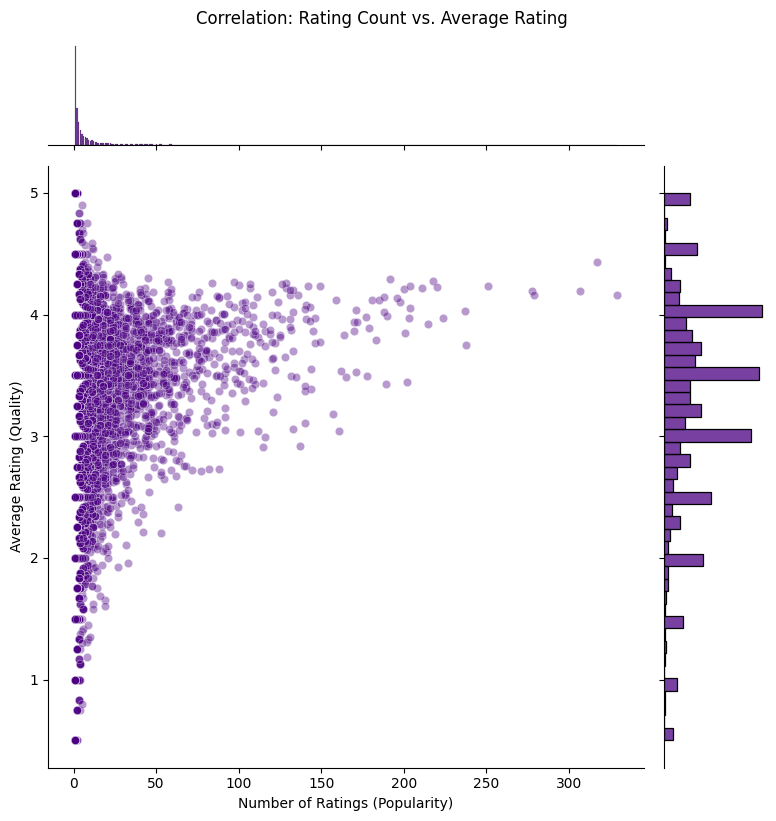

In [91]:
movie_quality = df.groupby('title')['rating'].agg(['mean', 'count'])

plt.figure(figsize=(10, 6))
sns.jointplot(x='count', y='mean', data=movie_quality, alpha=0.4, color='indigo', height=8)
plt.suptitle('Correlation: Rating Count vs. Average Rating', y=1.02)
plt.xlabel('Number of Ratings (Popularity)')
plt.ylabel('Average Rating (Quality)')
plt.show()

The scatter plot shows the relationship between movie popularity (number of ratings) and quality (average rating). Most movies have low rating counts, indicating sparsity, and display a wide range of ratings, while more popular movies tend to have more stable and consistent average ratings. This suggests that highly rated movies are not always the most popular, highlighting that popularity and quality are different, and an effective recommendation system should balance both factors rather than relying on one alone.

### 6.5 Distribution of Ratings per user 

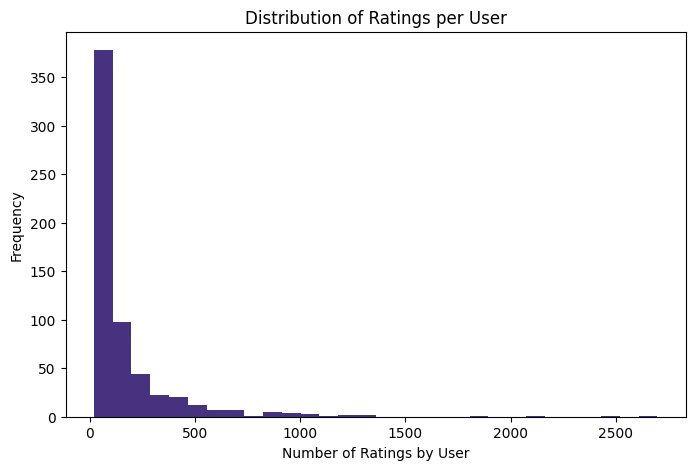

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

In [92]:
user_activity = ratings.groupby('userId').size()

plt.figure(figsize=(8,5))
plt.hist(user_activity, bins=30)
plt.title('Distribution of Ratings per User')
plt.xlabel('Number of Ratings by User')
plt.ylabel('Frequency')
plt.show()

user_activity.describe()

The distribution of ratings per user is highly skewed, with most users contributing only a small number of ratings while a few users are highly active. This imbalance highlights the sparsity of user interactions and reinforces the need for a hybrid recommendation approach to improve performance for users with limited rating history.

### 6.6 Average Rating per Genre

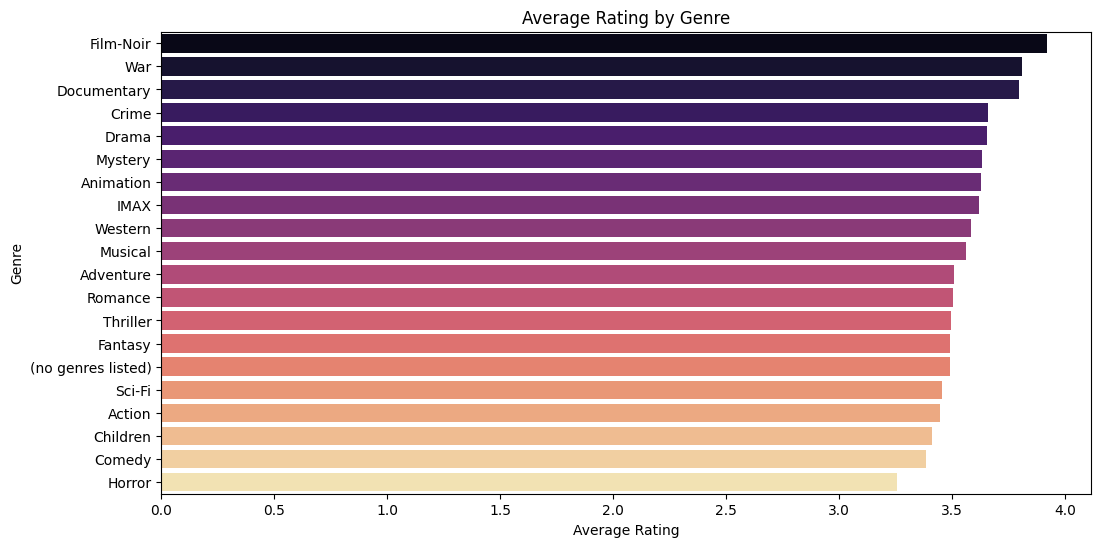

In [93]:
genre_stats = movie_ratings.copy()
genre_stats['genre'] = genre_stats['genres'].str.split('|')
genre_stats = genre_stats.explode('genre')

genre_avg = genre_stats.groupby('genre')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_avg.values, y=genre_avg.index, palette='magma')
plt.title('Average Rating by Genre')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.show()

Film-Noir, War, and Documentaries have the highest average ratings, indicating consistently strong quality despite fewer titles. In contrast, mainstream genres like Action and Comedy have lower averages due to more varied content and mixed audience reactions, while Horror ranks lowest, reflecting its niche appeal. Overall, genre averages help provide a baseline for comparing and normalizing ratings across different types of films.

### 6.7 Tags Analysis (Semantic insights)

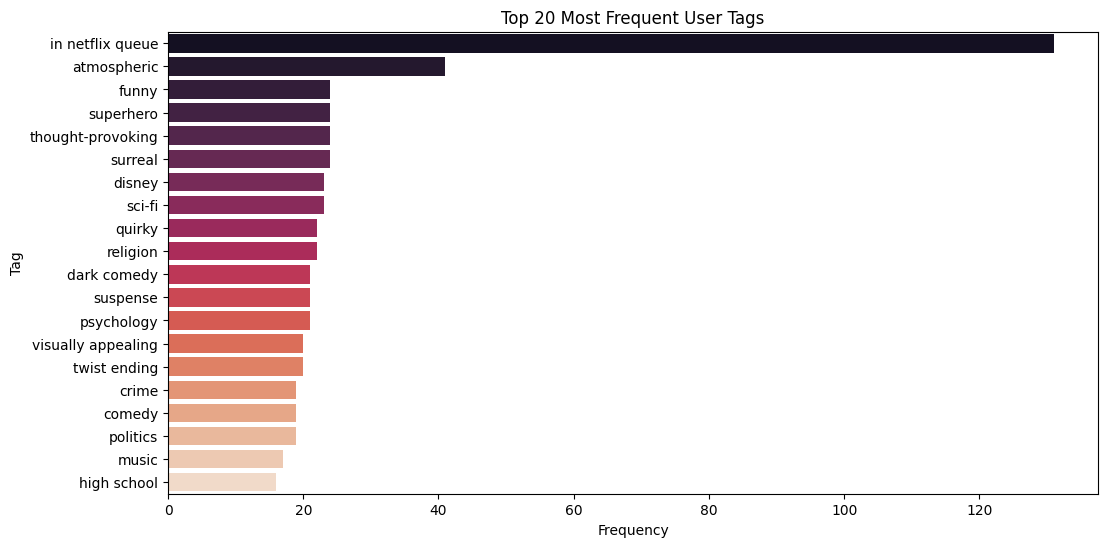

In [94]:
tags['tag_clean'] = tags['tag'].str.lower().str.strip()
top_tags = tags['tag_clean'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_tags.values, y=top_tags.index, palette='rocket')
plt.title('Top 20 Most Frequent User Tags')
plt.xlabel('Frequency')
plt.ylabel('Tag')
plt.show()

This chart shows the top 20 most frequent user-generated tags on the platform and how often they appear. It highlights the types of descriptive keywords users commonly associate with movies, such as themes, moods, or genres. The distribution indicates that a few tags are used very frequently while others appear less often, suggesting that user tagging behavior is somewhat concentrated around popular descriptors. These tags are valuable for content-based filtering, as they provide additional context about movies that can improve recommendation quality, especially in cold start scenarios.

### 6.8 Checking number of Tags per Movie

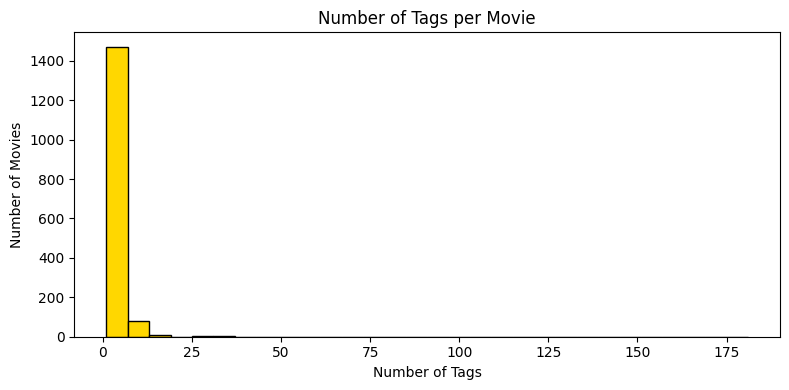

Average tags per movie : 2.3
Max tags on one movie  : 181


In [95]:
# How many tags does each movie have?
tags_per_movie = tags.groupby('movieId')['tag'].count()

plt.figure(figsize=(8, 4))
plt.hist(tags_per_movie, bins=30, color='gold', edgecolor='black')
plt.title('Number of Tags per Movie')
plt.xlabel('Number of Tags')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

print(f"Average tags per movie : {tags_per_movie.mean():.1f}")
print(f"Max tags on one movie  : {tags_per_movie.max()}")

In [96]:
# Which movies have the most tags?
most_tagged = (
    tags.groupby('movieId')['tag'].count()
    .reset_index()
    .rename(columns={'tag': 'n_tags'})
    .merge(movies[['movieId', 'title']], on='movieId')
    .nlargest(10, 'n_tags')
    [['title', 'n_tags']]
    .reset_index(drop=True)
)
print("\nTop 10 Most Tagged Movies:")
display(most_tagged)



Top 10 Most Tagged Movies:


,title,n_tags
0,Pulp Fiction (1994),181
1,Fight Club (1999),54
2,2001: A Space Odyssey (1968),41
3,Léon: The Professional (a.k.a. The Professiona...,35
4,Eternal Sunshine of the Spotless Mind (2004),34
5,"Big Lebowski, The (1998)",32
6,Donnie Darko (2001),29
7,Star Wars: Episode IV - A New Hope (1977),26
8,Inception (2010),26
9,Suicide Squad (2016),19


## 7. PRE-PROCESSING

## 7.1 Data Filtering (Denoising)
To ensure model reliability, we filter for movies with at least 10 ratings and users who have rated at least 5 movies.

In [97]:
# 1. Filter Movies: Keep those with 10 or more ratings
movie_counts = movie_ratings.groupby('movieId').size()
popular_movies = movie_counts[movie_counts >= 10].index
df_filtered = movie_ratings[movie_ratings['movieId'].isin(popular_movies)]

# 2. Filter Users: Keep those with 5 or more ratings
user_counts = df_filtered.groupby('userId').size()
active_users = user_counts[user_counts >=5 ].index
df_filtered = df_filtered[df_filtered['userId'].isin(active_users)]

print(f"Original records: {len(movie_ratings)}")
print(f"Filtered records: {len(df_filtered)}")
print(f"Movies kept: {df_filtered['movieId'].nunique()}")
print(f"Users kept: {df_filtered['userId'].nunique()}")

Original records: 100836
Filtered records: 81116
Movies kept: 2269
Users kept: 610


## MODELLING